In [74]:
import os
import json
import csv
import sys
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
from sklearn.metrics import roc_auc_score, average_precision_score
import tensorflow as tf
from sklearn.decomposition import PCA
from gae import obtain_ID
np.set_printoptions(threshold=sys.maxsize)


# Obtain graph features

- We provide the generated graph embeddings of Big-15 dataset from our paper. Please download the provided data and place it under /data folder
- The graph embeddings can be obtained by running generate_graph_embeddings.ipynb

In [75]:
path = '../data/graph_embeddings_big15/graph_embeddings_GAE'


file_list_em = os.listdir(path)
#print(file_list_em[:5])
        

graph_features = []
label = []
asm_id = []
asm_id_available = False

 
       
for filepath in file_list_em:
    

    fullpath = os.path.join(path, filepath)
    
    name = filepath.split("_")[1]

    data = np.load(fullpath)
    
    if data["success"]:
        if len(data["feature"])!=16:
            print("We have mismatch embeddings, length is {}".format(len(data["feature"])))
                  
        graph_features.append(np.reshape(data["feature"], [-1]))
        label.append(np.reshape(data["y"], [-1]))
        # if the asm_id field is available
        if "asm_id" in data.files:
            asm_id_available = True
            asm_id.append(np.reshape(data["asm_id"], [-1]))
        else: 
            # we simply append the index from the filename
            asm_id.append(np.reshape(name, [-1]))

graph_features = np.array(graph_features)
label=np.array(label)
asm_id = np.array(asm_id)





In [76]:
from sklearn.preprocessing import StandardScaler
scale_graph_features = StandardScaler().fit_transform(graph_features)

# TSNE Transformation + data visualization with original labels

- This will reproduce part of Figure 4. (left) in the paper

In [77]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300)
tsne_results_full = tsne.fit_transform(scale_graph_features)

/home/adrian/enter/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/home/adrian/enter/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 10711 samples in 0.001s...
[t-SNE] Computed neighbors for 10711 samples in 2.007s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10711
[t-SNE] Computed conditional probabilities for sample 2000 / 10711
[t-SNE] Computed conditional probabilities for sample 3000 / 10711
[t-SNE] Computed conditional probabilities for sample 4000 / 10711
[t-SNE] Computed conditional probabilities for sample 5000 / 10711
[t-SNE] Computed conditional probabilities for sample 6000 / 10711
[t-SNE] Computed conditional probabilities for sample 7000 / 10711
[t-SNE] Computed conditional probabilities for sample 8000 / 10711
[t-SNE] Computed conditional probabilities for sample 9000 / 10711
[t-SNE] Computed conditional probabilities for sample 10000 / 10711
[t-SNE] Computed conditional probabilities for sample 10711 / 10711
[t-SNE] Mean sigma: 0.280117
[t-SNE] KL divergence after 50 iterations with early exaggeration: 90.141083
[t-SNE] KL 

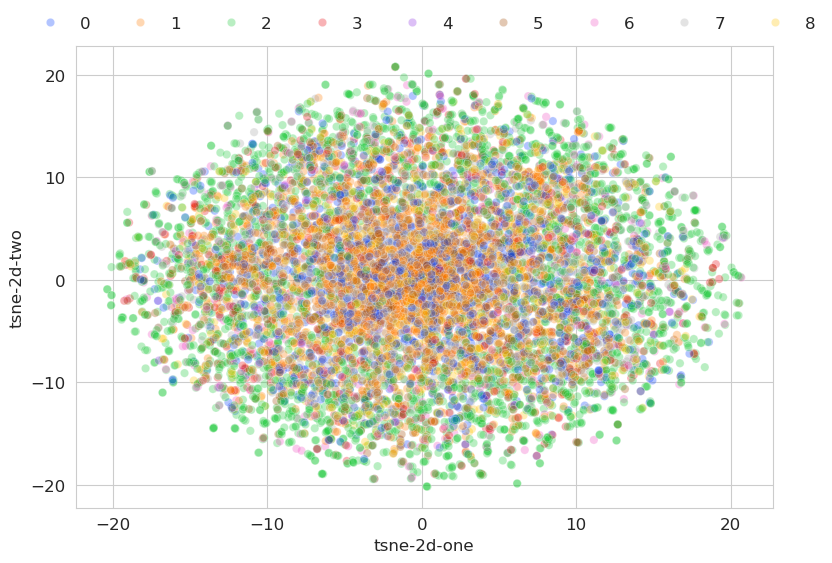

In [78]:

SMALL_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize


df_tsne_full = pd.DataFrame()

df_tsne_full['tsne-2d-one'] = tsne_results_full[:,0]
df_tsne_full['tsne-2d-two'] = tsne_results_full[:,1]
df_tsne_full['y'] = label

#colors = ['#747FE3', '#8EE35D', '#E37346', '#747FE3', '#8EE35D', '#E37346', '#747FE3', '#8EE35D', '#E37346', ]
#sns.color_palette("cubehelix", as_cmap=True)
#sns.set_palette("pastel")

sns.set_style("whitegrid")
plt.figure(figsize=(9,6))
ax = sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="y",
    palette="bright",
    #palette = colors,
    #palette=sns.color_palette("hls", 9),
    data=df_tsne_full,
    legend="full",
    alpha=0.3
)

sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=9, title=None, frameon=False,
)

#plt.scatter(data[:, 0], data[:, 1])
#plt.show()

# Weighted Concensus clustering to generate cluster labels (Section III-A2)
- Stage 1: Apply invidiual clustering algorithms

## HDBSCAN

In [79]:
import hdbscan
from sklearn import metrics
from sklearn.metrics import pairwise_distances

hdb = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=2).fit(scale_graph_features)
hdbscan_labels = hdb.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise_ = list(hdbscan_labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)


print(metrics.silhouette_score(scale_graph_features , hdbscan_labels, metric='euclidean'))

Estimated number of clusters: 3
Estimated number of noise points: 1477
0.23681037


## K-means

Text(0.5, 1.0, 'Different Inertia Values for Different Number of Clusters')

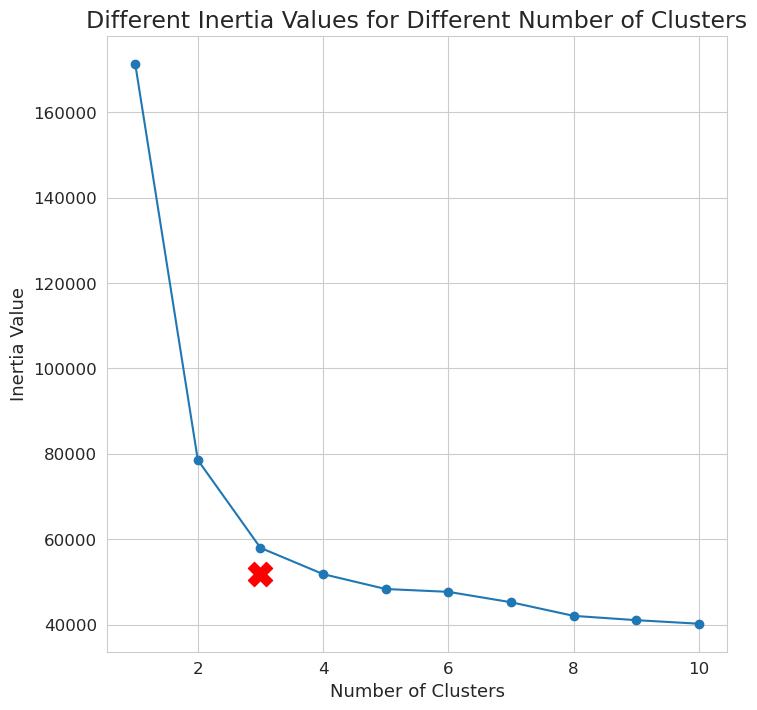

In [80]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [8,8]
sns.set_style("whitegrid")
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

inertia_list = []
for num_clusters in range(1, 11):
    kmeans_model = KMeans(n_clusters=num_clusters, init="k-means++")
    kmeans_model.fit(scale_graph_features)
    inertia_list.append(kmeans_model.inertia_)
    
# plot the inertia curve
plt.plot(range(1,11),inertia_list)
plt.scatter(range(1,11),inertia_list)
plt.scatter(3, inertia_list[3], marker="X", s=300, c="r")
plt.xlabel("Number of Clusters", size=13)
plt.ylabel("Inertia Value", size=13)
plt.title("Different Inertia Values for Different Number of Clusters", size=17)

In [81]:
from sklearn.cluster import KMeans

#we choose the n_clusters =4 to reduce the number of the noisy points

kmeans = KMeans(n_clusters=4, random_state=0,  init="k-means++").fit(scale_graph_features)
kmeans_labels = kmeans.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(kmeans_labels)) - (1 if -1 in kmeans_labels else 0)
n_noise_ = list(kmeans_labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

from sklearn import metrics
from sklearn.metrics import pairwise_distances

print(metrics.silhouette_score(scale_graph_features , kmeans_labels, metric='euclidean'))

Estimated number of clusters: 4
Estimated number of noise points: 0
0.96628684


## GMM 

In [82]:
from sklearn.mixture import GaussianMixture

# we use BIC Score to select the best number of clusters and covariance type
# From the grid search process , n_components=4, covariance_type = "full" result in the lowest BIC score
# More details can be found https://scikit-learn.org/dev/auto_examples/mixture/plot_gmm_selection.html

gm = GaussianMixture(n_components=4, covariance_type = "full", random_state=0).fit(scale_graph_features)

gmm_labels = gm.predict(scale_graph_features)

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(gmm_labels)) - (1 if -1 in gmm_labels else 0)
n_noise_ = list(gmm_labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)


print(metrics.silhouette_score(scale_graph_features , gmm_labels, metric='euclidean'))

Estimated number of clusters: 4
Estimated number of noise points: 0
-0.033040695


# Weighted Concensus clustering to generate cluster labels (Section III-A2)
- Stage 2: weighted consensus clustering 

## Construct concensus matrix

In [83]:
cluster_assignments ={#"original":label,
           "hdbscan": hdbscan_labels,
           "kmeans":kmeans_labels,
           "gmm":gmm_labels}

#weights of each clustering solution based on the silhouette coefficient (Equation 13 in the paper)
coefficient_assignments = {#"original":(-0.11+1)/2,
           "hdbscan": (0.23+1)/2,
           "kmeans":(0.96+1)/2,
           "gmm":(-0.033+1)/2}

In [84]:
import numpy as np

N = scale_graph_features.shape[0]
consensus_matrix = np.zeros((N, N))

# Assume cluster_assignments is a list of K arrays representing cluster assignments for each solution
for k in cluster_assignments.keys():
    cluster_assignment_k = cluster_assignments[k]
    coefficient_assignment_k = coefficient_assignments[k]

    for i in range(N):
        for j in range(i + 1, N):
            # Check if data points i and j are clustered together in solution k
            if cluster_assignment_k[i] !=-1 and cluster_assignment_k[j]!=-1 and cluster_assignment_k[i] == cluster_assignment_k[j]:
                consensus_matrix[i, j] += 1*coefficient_assignment_k
                consensus_matrix[j, i] += 1*coefficient_assignment_k
                
                
consensus_matrix = consensus_matrix/3.0

print(consensus_matrix.shape)



(10711, 10711)


## Apply PCA to reduce dimension

In [85]:
print(consensus_matrix.shape)

pca = PCA(30)
new_consensus_matrix = pca.fit_transform(consensus_matrix)

print(sum(pca.explained_variance_ratio_))

(10711, 10711)
0.9955251197275086


## GMM

In [86]:
#### BIC Score to select the best number of clusters 

from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV


def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)


param_grid = {
    "n_components": range(1, 8),
    "covariance_type": ["spherical", "tied", "diag", "full"],
}
grid_search = GridSearchCV(
    GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
)
grid_search.fit(new_consensus_matrix)

GridSearchCV(estimator=GaussianMixture(),
             param_grid={'covariance_type': ['spherical', 'tied', 'diag',
                                             'full'],
                         'n_components': range(1, 8)},
             scoring=<function gmm_bic_score at 0x70f02c965ee0>)

In [87]:
import pandas as pd

df_gmm_con = pd.DataFrame(grid_search.cv_results_)[
    ["param_n_components", "param_covariance_type", "mean_test_score"]
]
df_gmm_con["mean_test_score"] = -df_gmm_con["mean_test_score"]
df_gmm_con = df_gmm_con.rename(
    columns={
        "param_n_components": "Number of components",
        "param_covariance_type": "Type of covariance",
        "mean_test_score": "BIC score",
    }
)
df_gmm_con.sort_values(by="BIC score").head()

,Number of components,Type of covariance,BIC score
17,4,diag,-523712.601824
16,3,diag,-507631.068724
3,4,spherical,-493439.846991
15,2,diag,-395567.288930
2,3,spherical,-376345.461050


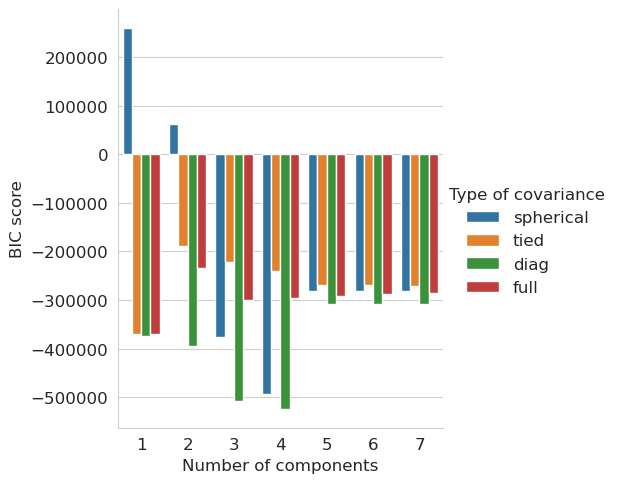

In [88]:
import seaborn as sns

sns.catplot(
    data=df_gmm_con,
    kind="bar",
    x="Number of components",
    y="BIC score",
    hue="Type of covariance",
)
plt.show()

In [89]:
from sklearn.mixture import GaussianMixture

# we use BIC Score to select the best number of clusters and covariance type
# From the grid search process , n_components=4, covariance_type = "diag" result in the lowest BIC score

gm = GaussianMixture(n_components=4, random_state=0, covariance_type = "diag").fit(new_consensus_matrix)

gmm_concensus_labels = gm.predict(new_consensus_matrix)

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(gmm_concensus_labels )) - (1 if -1 in gmm_concensus_labels  else 0)
n_noise_ = list(gmm_concensus_labels ).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 4
Estimated number of noise points: 0


# TSNE Transformation + data visulization with new cluster labels

- This will reproduce part of Figure 4. (right) in the paper

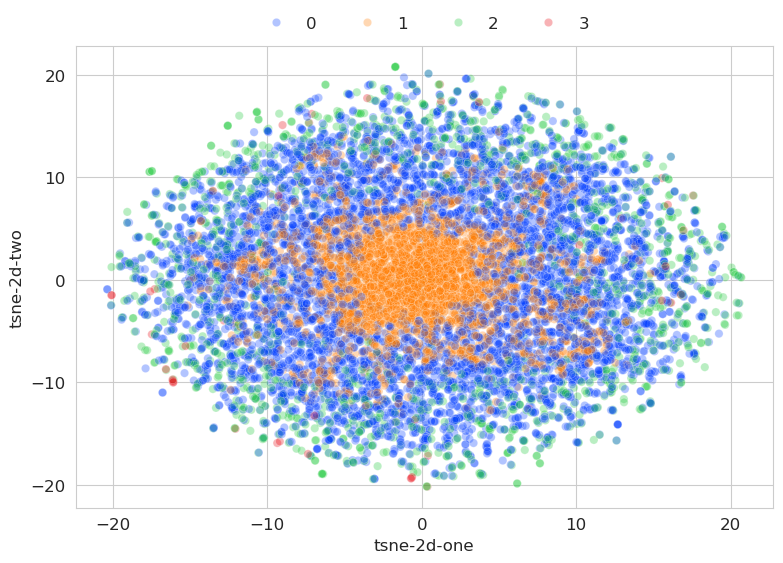

In [90]:
df_tsne_full['tsne-2d-one'] = tsne_results_full[:,0]
df_tsne_full['tsne-2d-two'] = tsne_results_full[:,1]
df_tsne_full['y'] = gmm_concensus_labels 

plt.figure(figsize=(9,6))
ax = sns.scatterplot(
    x="tsne-2d-one", y="tsne-2d-two",
    hue="y",
    palette="bright",
    #palette=sns.color_palette("hls", 10),
    data=df_tsne_full,
    legend="full",
    alpha=0.3
)


#plt.scatter(data[:, 0], data[:, 1])
#plt.show()
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=4, title=None, frameon=False,
)






# Save the cluster label to CSV (optional)

- We need to carefully map the new label to the correct malware id


In [91]:
def correct_malwareid_list(asm_id_available):
    if not asm_id_available:
        # obtain the list of malware samples ids
        path =  '../data/graph_features/big-15/cfg_embeddings/cfg_embeddings'

        file_list = os.listdir(path)
        file_list_x_y = list(filter(lambda x: '_sparse_matrix' not in x and '.npz' in x, file_list))

        obtain_id= obtain_ID(path, file_list_x_y) 
        file_list = obtain_id.read()
        file_list = [x.split("_")[2].split(".")[0] for x in file_list]

        #convert the malware list to the correct order that correspond to new label order
        hash_id = []

        for index in asm_id: 
            hash_id.append(np.reshape(file_list[int(index[0])], [-1]))

        hash_id = np.array(hash_id)
        
        return hash_id

    else: 
        return asm_id
        



In [92]:
asm_id = correct_malwareid_list(asm_id_available)

# concatenate the id with the new label
gmm_concensus_labels = np.reshape(gmm_concensus_labels, [-1,1])
data_label_gmm= np.concatenate((asm_id, gmm_concensus_labels), 1)

data_label_gmm= pd.DataFrame(data_label_gmm,
                   columns=['asm_id', "Class"])

data_label_gmm.head(5)

#data_label_gmm.to_csv("/path_to_file/new_gmm_labels_id.csv")

,asm_id,Class
0,dJwlcq0EsPRymQWS9X6v,1
1,HJux0O46yzU7XF5slVQA,2
2,9nR0ZHP7X2YJhQu3Nzsa,0
3,2cmq9yIzWOA8apYwRekT,0
4,dAN7DBVpI8Yh4snj0zoO,1
